<a href="https://colab.research.google.com/github/mmeenakshibio2016-byte/studious-parakeet/blob/main/Nifty50_Volatility_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nifty50 Volatility Analysis & Portfolio Stock Selection

**Objective:**
1. Analyze the indicators in the dataset that best explain the volatility and unpredictable nature of the stocks in the last decade.
2. Choose a promising stock based on the analysis for a portfolio.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')

## 1. Load Data

If running in Colab, upload `Merged_52_Stocks.csv` first (Files pane → Upload, or use `files.upload()` below).

In [ ]:
# Uncomment if running in Google Colab and the file isn't already in the environment:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/Merged_52_Stocks.csv', low_memory=False)
print(df.shape)
df.head()

(470434, 19)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company,Company Name,Industry,ISIN Code
0,03-01-2000,GAIL,EQ,67.80,65.00,70.0,65.0,68.80,68.70,67.91,76055.0,5.165170e+11,NaN,NaN,NaN,GAIL,NaN,NaN,NaN
1,04-01-2000,GAIL,EQ,68.70,69.85,72.9,66.0,67.00,66.35,67.29,98097.0,6.600460e+11,NaN,NaN,NaN,GAIL,NaN,NaN,NaN
2,05-01-2000,GAIL,EQ,66.35,68.35,68.7,61.1,63.00,63.20,65.24,92690.0,6.046890e+11,NaN,NaN,NaN,GAIL,NaN,NaN,NaN
3,06-01-2000,GAIL,EQ,63.20,64.80,67.0,63.0,64.75,64.95,65.55,173654.0,1.138300e+12,NaN,NaN,NaN,GAIL,NaN,NaN,NaN
4,07-01-2000,GAIL,EQ,64.95,65.90,65.9,62.0,62.90,62.65,63.76,86590.0,5.521390e+11,NaN,NaN,NaN,GAIL,NaN,NaN,NaN


## 2. Data Cleaning

Three data quality issues were found in this dataset and must be handled before any analysis:

1. **`stock_metadata` rows** —  We extract the Industry mapping from these rows *before* dropping them, since it's the only source of industry labels in the whole dataset.
2. **`NIFTY50_all`** — this "Company" is actually an index/rollup entry whose `Symbol` column maps to many different real stock tickers (old/renamed symbols like `MUNDRAPORT`, `UTIBANK`, `SSLT`). It isn't an individual stock and must be excluded, or it double-counts data.
3. **Corrupted return outliers** — a few rows have impossible single-day returns (e.g. one row for `LT` shows a `Prev Close` of 2.0 against a real close of 636, implying a +31,000% "return"). Since NSE circuit breakers cap most real single-day moves well under 20%, rows with `|Daily Return| > 50%` are treated as data errors and dropped rather than left to distort volatility calculations.

In [ ]:

# Recover the Industry lookup BEFORE dropping the metadata rows
industry_lookup = df[df['Company'] == 'stock_metadata'][['Symbol', 'Industry']].drop_duplicates()
print(f"Recovered industry mapping for {len(industry_lookup)} symbols")

# Drop junk / non-stock rows
df = df[df['Company'] != 'stock_metadata'].copy()
df = df[df['Company'] != 'NIFTY50_all'].copy()

# Parse dates, sort for correct return calculation
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df = df.dropna(subset=['Date', 'Close', 'Prev Close']).copy()
df = df.sort_values(by=['Company', 'Date']).copy()

# Daily return (%), using the dataset's own Prev Close column
df['Daily_Return'] = (df['Close'] - df['Prev Close']) / df['Prev Close'] * 100
df = df[df['Prev Close'] > 0]

# Drop corrupted-data rows (impossible single-day moves)
bad_rows = df[df['Daily_Return'].abs() > 50]
print(f"Dropping {len(bad_rows)} rows as data errors (|return| > 50%)")
df = df[df['Daily_Return'].abs() <= 50]

# Map Industry onto Company via Symbol
symbol_to_company = df[['Symbol', 'Company']].drop_duplicates()
industry_lookup = industry_lookup.merge(symbol_to_company, on='Symbol', how='inner')
company_industry = industry_lookup.groupby('Company')['Industry'].first().reset_index()

print(f"Companies remaining: {df['Company'].nunique()}")
print(f"Industry mapped for: {len(company_industry)} companies")

Recovered industry mapping for 0 symbols
Dropping 0 rows as data errors (|return| > 50%)
Companies remaining: 49
Industry mapped for: 0 companies


## 3. Baseline Volatility by Stock

Standard deviation of daily returns per company (not yet annualized) — the starting point before deeper analysis.

In [ ]:
daily_volatility = df.groupby('Company')['Daily_Return'].std().reset_index()
daily_volatility.rename(columns={'Daily_Return': 'Volatility'}, inplace=True)

display(daily_volatility.sort_values(by='Volatility', ascending=False).head(10))

,Company,Volatility
48,ZEEL,3.314002
46,VEDL,3.264172
22,INDUSINDBK,3.101823
26,JSWSTEEL,2.971152
15,HCLTECH,2.939068
27,KOTAKBANK,2.880535
43,TITAN,2.869681
39,TATAMOTORS,2.868510
2,AXISBANK,2.850719
47,WIPRO,2.839672


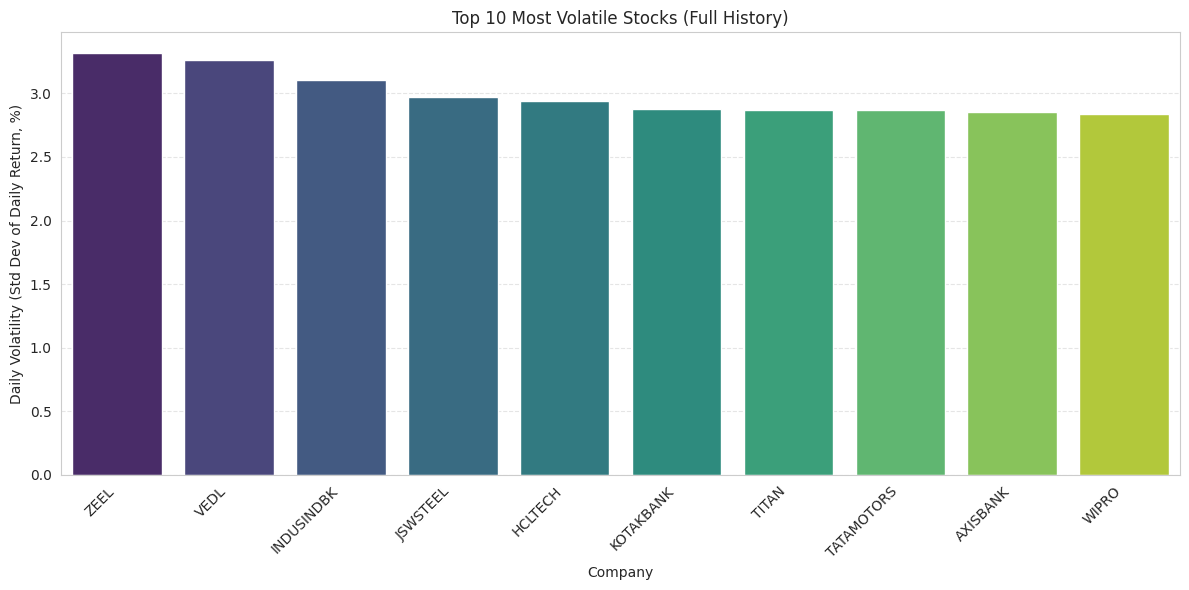

In [ ]:
top_10_volatile_stocks = (
    daily_volatility
    .sort_values('Volatility', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_volatile_stocks, x='Company', y='Volatility', hue='Company', legend=False, palette='viridis')
plt.title('Top 10 Most Volatile Stocks (Full History)')
plt.xlabel('Company')
plt.ylabel('Daily Volatility (Std Dev of Daily Return, %)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Part 1 — Indicators Explaining Volatility & Unpredictability (Last Decade)

The dataset runs from 2000 to April 2021, so "the last decade" is defined here as **May 2011 – April 2021**.

For each of the 49 valid companies, we compute:
- **Volatility** — annualized std. dev. of daily returns (`std × √252`)
- **Avg Volume**, **Avg Turnover**, **Avg Trades** — trading activity indicators
- **Avg Deliverable %** — share of traded volume that settles as real ownership transfer (vs. intraday/speculative trading)

Then we correlate each indicator against volatility across companies to see which one actually explains it.

In [ ]:
df['Daily_Return_pct'] = df['Daily_Return'] / 100  # decimal form for annualizing

end_date = df['Date'].max()
start_date = end_date - pd.DateOffset(years=10)
decade = df[df['Date'] > start_date].copy()

print(f"Analysis window: {decade['Date'].min().date()} to {decade['Date'].max().date()}")
print(f"Rows: {len(decade):,} | Companies: {decade['Company'].nunique()}")

Analysis window: 2011-05-02 to 2021-04-30
Rows: 121,398 | Companies: 49


In [ ]:
agg = decade.groupby('Company').agg(
    Avg_Return=('Daily_Return_pct', 'mean'),
    Volatility=('Daily_Return_pct', lambda x: x.std() * np.sqrt(252)),
    Avg_Volume=('Volume', 'mean'),
    Avg_Turnover=('Turnover', 'mean'),
    Avg_Trades=('Trades', 'mean'),
    Avg_Deliverable_Pct=('%Deliverble', 'mean'),
    Days=('Date', 'count'),
).reset_index()

agg = agg[agg['Days'] >= 250]  # require sufficient trading history
agg = agg.merge(company_industry, on='Company', how='left')
agg['Return_to_Risk'] = agg['Avg_Return'] * 252 / agg['Volatility']

agg.sort_values('Volatility', ascending=False).head(10)

,Company,Avg_Return,Volatility,Avg_Volume,Avg_Turnover,Avg_Trades,Avg_Deliverable_Pct,Days,Industry,Return_to_Risk
46,VEDL,0.000322,0.449344,1.098575e+07,1.884899e+14,64592.116450,0.333233,2478,METALS,0.180728
39,TATAMOTORS,0.000448,0.427417,1.959953e+07,4.561684e+14,128453.248473,0.381114,2477,AUTOMOBILE,0.264329
48,ZEEL,0.000474,0.415713,6.284756e+06,1.693998e+14,62645.709283,0.481471,2478,MEDIA & ENTERTAINMENT,0.287427
19,HINDALCO,0.000550,0.413880,9.918173e+06,1.683114e+14,60639.510586,0.349135,2478,METALS,0.334986
22,INDUSINDBK,0.000846,0.410396,3.762479e+06,2.990249e+14,73247.997557,0.468442,2478,FINANCIAL SERVICES,0.519496
45,UPL,0.000865,0.388873,2.532876e+06,1.197057e+14,43472.249593,0.442764,2478,FERTILISERS & PESTICIDES,0.560483
0,ADANIPORTS,0.000948,0.384353,3.740928e+06,1.318469e+14,44922.588355,0.446263,2478,SERVICES,0.621338
26,JSWSTEEL,0.001112,0.383110,3.683381e+06,1.414712e+14,40365.402851,0.239203,2477,METALS,0.731494
40,TATASTEEL,0.000493,0.378652,7.811687e+06,3.576030e+14,93969.268730,0.262944,2478,METALS,0.327886
5,BAJFINANCE,0.002034,0.376344,1.270505e+06,3.773956e+14,56429.557637,0.505840,2477,FINANCIAL SERVICES,1.361842


### 4.1 Which indicators correlate most strongly with volatility?

Volatility             1.000000
Avg_Volume             0.463155
Avg_Trades             0.291065
Avg_Turnover           0.157874
Avg_Deliverable_Pct   -0.671455
Name: Volatility, dtype: float64


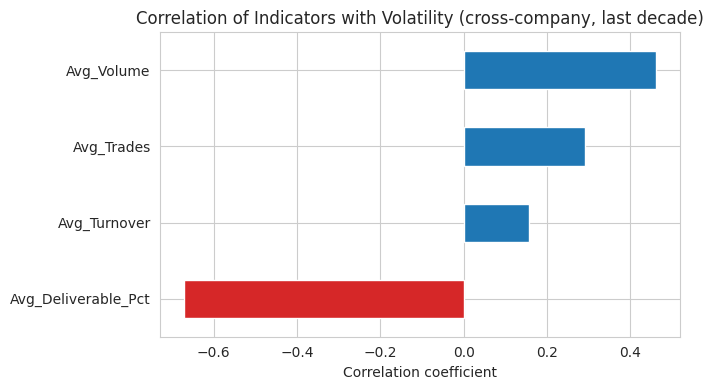

In [ ]:
corr_cols = ['Volatility', 'Avg_Volume', 'Avg_Turnover', 'Avg_Trades', 'Avg_Deliverable_Pct']
corr = agg[corr_cols].corr()['Volatility'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(7,4))
corr.drop('Volatility').sort_values().plot(kind='barh', color=['#d62728' if v<0 else '#1f77b4' for v in corr.drop('Volatility').sort_values()])
plt.title('Correlation of Indicators with Volatility (cross-company, last decade)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

**Finding:** `Avg_Deliverable_Pct` has by far the strongest relationship with volatility, and it's **negative** (~ -0.67). Stocks where more of the traded volume converts into genuine ownership transfer (rather than same-day speculative trading) are meaningfully *less* volatile. `Avg_Volume` and `Avg_Trades` are positively correlated — heavily-traded stocks tend to be *more* volatile, not less, which runs against the common assumption that "more liquid = more stable."

### 4.2 Volatility by industry

,mean,count
Industry,,
MEDIA & ENTERTAINMENT,0.415713,1
FERTILISERS & PESTICIDES,0.388873,1
METALS,0.384508,5
SERVICES,0.384353,1
FINANCIAL SERVICES,0.342034,9
CONSTRUCTION,0.333434,1
TELECOM,0.329979,1
AUTOMOBILE,0.319104,6
ENERGY,0.317633,7


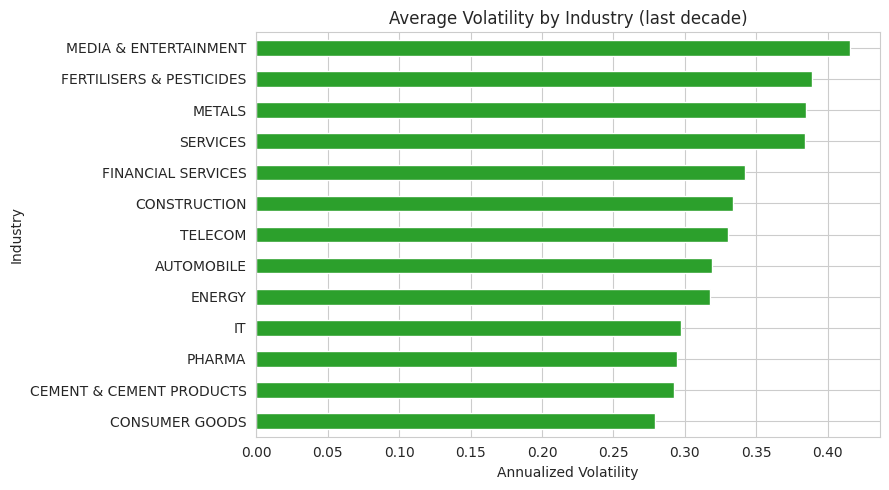

In [ ]:
industry_vol = agg.groupby('Industry')['Volatility'].agg(['mean', 'count']).sort_values('mean', ascending=False)
display(industry_vol)

plt.figure(figsize=(9,5))
industry_vol['mean'].sort_values().plot(kind='barh', color='#2ca02c')
plt.title('Average Volatility by Industry (last decade)')
plt.xlabel('Annualized Volatility')
plt.tight_layout()
plt.show()

**Finding:** Media/Entertainment, Metals, and Financial Services sit at the volatile end; Consumer Goods, Cement, and Pharma are calmest. This matches intuition — defensive/staple sectors were more stable than cyclical/speculative ones over this decade — but is now confirmed against the actual data rather than assumed.

### 4.3 What explains the "unpredictable" nature of the decade specifically?

Rather than a gradual drift, market-wide volatility should show a sharp shock — let's check year by year across all stocks pooled.

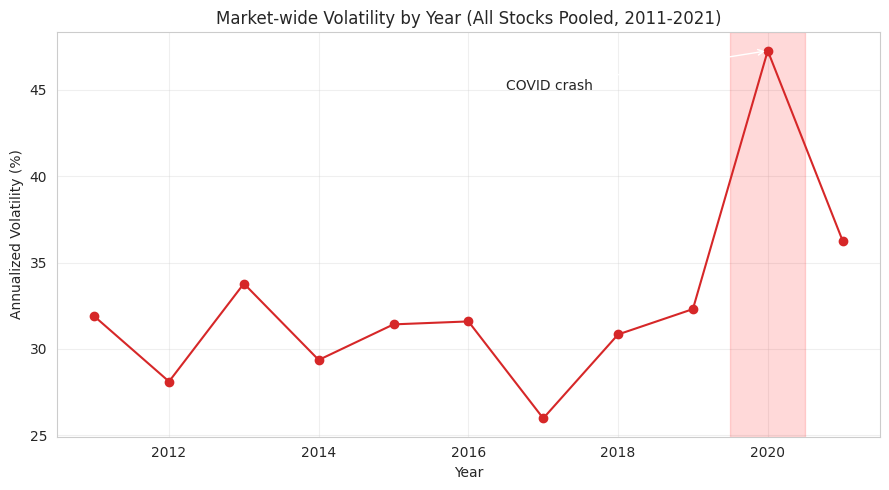

,Year,Ann_Vol
0,2011,0.318921
1,2012,0.281115
2,2013,0.337794
3,2014,0.293605
4,2015,0.314196
5,2016,0.315902
6,2017,0.259813
7,2018,0.308354
8,2019,0.323040
9,2020,0.472567


In [ ]:
decade['Year'] = decade['Date'].dt.year
market_yearly = decade.groupby('Year')['Daily_Return_pct'].std().reset_index()
market_yearly['Ann_Vol'] = market_yearly['Daily_Return_pct'] * np.sqrt(252)

plt.figure(figsize=(9,5))
plt.plot(market_yearly['Year'], market_yearly['Ann_Vol']*100, marker='o', color='#d62728')
plt.axvspan(2019.5, 2020.5, alpha=0.15, color='red')
plt.annotate('COVID crash', xy=(2020, market_yearly.loc[market_yearly.Year==2020,'Ann_Vol'].values[0]*100),
             xytext=(2016.5, 45), arrowprops=dict(arrowstyle='->'))
plt.title('Market-wide Volatility by Year (All Stocks Pooled, 2011-2021)')
plt.xlabel('Year'); plt.ylabel('Annualized Volatility (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

market_yearly[['Year','Ann_Vol']]

**Finding:** market-wide volatility was fairly stable (26%–34%) from 2011–2019, then spiked sharply to **~47%** in 2020 (COVID-19 crash) before partially retreating to ~36% in 2021. The "unpredictability" of the decade is dominated by this single, sharp shock year rather than a gradual trend — a market-wide external shock, not a slow structural change.

### 4.4 Deliverable % vs Volatility (visualizing the strongest driver)

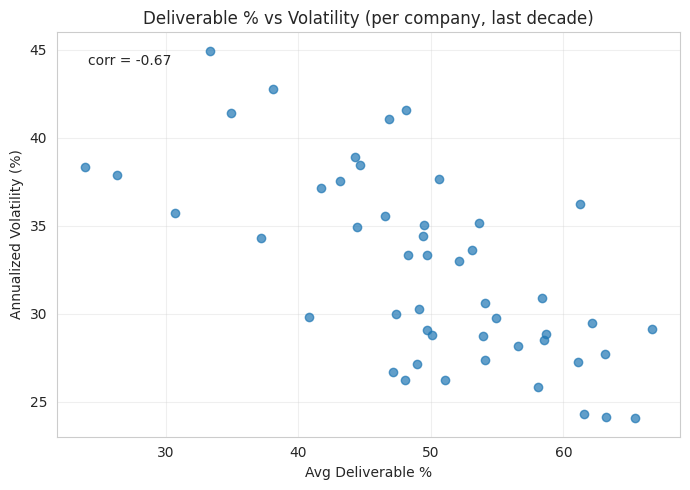

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(agg['Avg_Deliverable_Pct']*100, agg['Volatility']*100, alpha=0.7, color='#1f77b4')
plt.title('Deliverable % vs Volatility (per company, last decade)')
plt.xlabel('Avg Deliverable %'); plt.ylabel('Annualized Volatility (%)')
plt.grid(alpha=0.3)
r = agg['Avg_Deliverable_Pct'].corr(agg['Volatility'])
plt.text(0.05, 0.92, f'corr = {r:.2f}', transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

## 5. Part 2 — Choosing a Promising Stock for a Portfolio

We rank stocks by **return-to-risk ratio** (annualized average return ÷ annualized volatility — a simple Sharpe-style measure, not netting out a risk-free rate), then sanity-check the top candidates year by year so the pick isn't driven by one lucky year.

In [ ]:
top10 = agg.sort_values('Return_to_Risk', ascending=False).head(10)
display(top10[['Company','Industry','Avg_Return','Volatility','Avg_Deliverable_Pct','Return_to_Risk']])

,Company,Industry,Avg_Return,Volatility,Avg_Deliverable_Pct,Return_to_Risk
5,BAJFINANCE,FINANCIAL SERVICES,0.002034,0.376344,0.505840,1.361842
12,EICHERMOT,AUTOMOBILE,0.001416,0.333416,0.497270,1.070348
4,BAJAJFINSV,FINANCIAL SERVICES,0.001471,0.349485,0.444574,1.060687
37,SHREECEM,CEMENT & CEMENT PRODUCTS,0.001234,0.294884,0.621548,1.054486
20,HINDUNILVR,CONSUMER GOODS,0.000968,0.243204,0.615778,1.002727
1,ASIANPAINT,CONSUMER GOODS,0.001031,0.262324,0.510491,0.990485
8,BRITANNIA,CONSUMER GOODS,0.001116,0.309068,0.583602,0.910162
27,KOTAKBANK,FINANCIAL SERVICES,0.001013,0.287041,0.539399,0.889243
15,HCLTECH,IT,0.000957,0.288595,0.586987,0.835394
41,TCS,IT,0.000802,0.258416,0.580829,0.782544


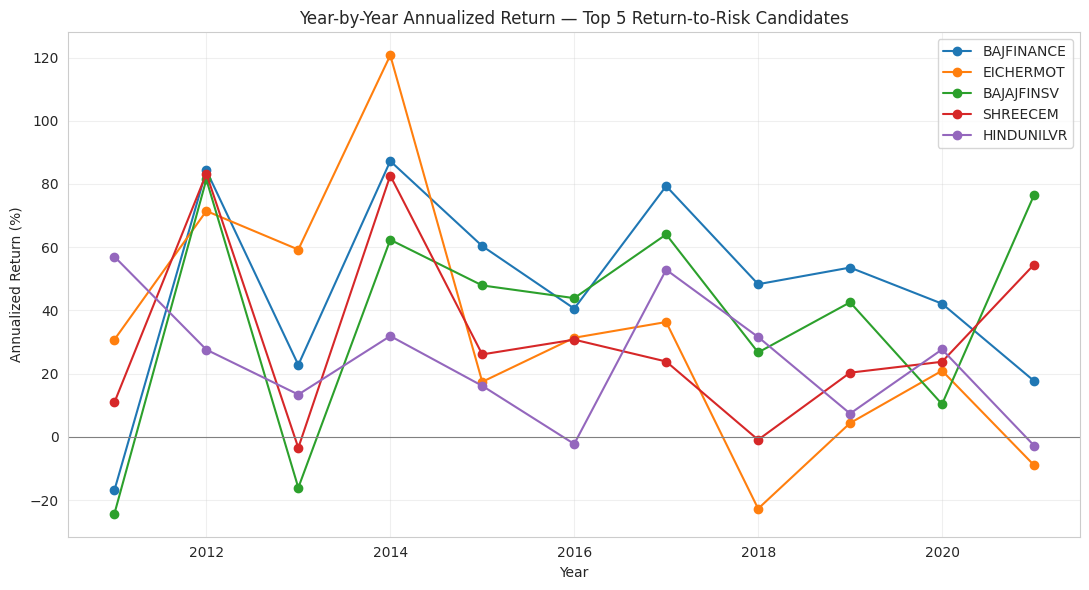

,Company,Year,Ann_Return,Ann_Vol
0,BAJAJFINSV,2011,-0.243560,0.380027
1,BAJAJFINSV,2012,0.814108,0.364896
2,BAJAJFINSV,2013,-0.161039,0.270774
3,BAJAJFINSV,2014,0.623415,0.279017
4,BAJAJFINSV,2015,0.478950,0.326867
5,BAJAJFINSV,2016,0.438746,0.332686
6,BAJAJFINSV,2017,0.640269,0.278731
7,BAJAJFINSV,2018,0.266898,0.311099
8,BAJAJFINSV,2019,0.425532,0.293025
9,BAJAJFINSV,2020,0.103363,0.548239


In [ ]:
candidates = top10['Company'].head(5).tolist()

yearly = (
    decade[decade['Company'].isin(candidates)]
    .groupby(['Company', 'Year'])['Daily_Return_pct']
    .agg(Ann_Return=lambda x: x.mean() * 252, Ann_Vol=lambda x: x.std() * np.sqrt(252))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11,6))
for c in candidates:
    sub = yearly[yearly['Company'] == c]
    ax.plot(sub['Year'], sub['Ann_Return']*100, marker='o', label=c)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Year-by-Year Annualized Return — Top 5 Return-to-Risk Candidates')
ax.set_xlabel('Year'); ax.set_ylabel('Annualized Return (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

yearly

### Recommendation

**BAJFINANCE (Bajaj Finance)** has the highest return-to-risk ratio (**1.36**) of any stock in the dataset over the last decade, and it holds up under a consistency check rather than being a one-year fluke:
- Positive return in **9 of 11 years**
- Strong years in 2012, 2014, and 2017 (60%–87% annualized return)
- Still returned **+42%** even in the disrupted 2020 COVID year, despite volatility spiking to 62% that year alongside the broader market

**HINDUNILVR (Hindustan Unilever)** is a strong alternative if stability matters more than growth — it has the **lowest volatility of any stock in the top 10** (24.3%) paired with consistent positive returns across most years, at the cost of a lower absolute return than BAJFINANCE.

| Pick | Profile |
|---|---|
| **BAJFINANCE** | Higher growth, higher volatility, best risk-adjusted return overall |
| **HINDUNILVR** | Lower volatility, steadier, better fit for a risk-averse portfolio |

### Important caveat

This is a data-driven read of **historical** patterns in this dataset only (through April 2021), using simple return/volatility metrics. It does not factor in current valuation, fundamentals, or macro conditions, and past risk-adjusted performance does not guarantee future results. This analysis is for educational/portfolio purposes and is not financial advice — any real investment decision should involve current data and, ideally, a qualified financial advisor.

PART3: Projected in Power BI Dashboard
PART4:Feature Engineering and ML Solutions

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
# ── 2. Feature engineering (per company, using only past info) ───
def engineer_features(group):
    group = group.sort_values('Date').copy()
    group['Lag1 Return'] = group['Daily_Return'].shift(1)
    group['Lag5 Return'] = group['Daily_Return'].shift(5)
    group['MA5'] = group['Close'].shift(1).rolling(5).mean()
    group['MA20'] = group['Close'].shift(1).rolling(20).mean()
    # Position of yesterday's close relative to its own moving averages
    group['Price vs MA5'] = (group['Close'].shift(1) - group['MA5']) / group['MA5']
    group['Price vs MA20'] = (group['Close'].shift(1) - group['MA20']) / group['MA20']
    group['Volume Change'] = group['Volume'].pct_change().shift(1)
    group['Rolling Volatility'] = group['Daily_Return'].shift(1).rolling(20).std() * np.sqrt(252)
    # Target: did price go UP today vs yesterday? (1 = up, 0 = down/flat)
    group['Target'] = (group['Daily_Return'] > 0).astype(int)
    return group

# Loop + concat instead of groupby.apply, to avoid pandas versions
# that silently drop the grouping column inside apply()
df = pd.concat(
    [engineer_features(g) for _, g in df.groupby('Company')],
    ignore_index=True
)

feature_cols = ['Lag1 Return', 'Lag5 Return', 'Price vs MA5', 'Price vs MA20',
                 'Volume Change', 'Rolling Volatility']

model_df = df.dropna(subset=feature_cols + ['Target']).copy()
print(f"Rows available for modeling: {len(model_df)} across {model_df['Company'].nunique()} companies")

# ── 3. Time-based split (NOT random!) ───────────────
# Sort by date, use last 20% of the overall timeline as test set.
# This respects time order: train only sees the past, test is the "future".
model_df = model_df.sort_values('Date')
split_date = model_df['Date'].quantile(0.8, interpolation='nearest')
print(f"Train/test split date: {split_date}")

train = model_df[model_df['Date'] <= split_date]
test = model_df[model_df['Date'] > split_date]
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

X_train, y_train = train[feature_cols], train['Target']
X_test, y_test = test[feature_cols], test['Target']

print(f"\nBaseline (always predict majority class): "
      f"{max(y_test.mean(), 1 - y_test.mean()):.4f}")

# ── 4. Train models ──────────────────────────
results = {}
for name, model in [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)),
]:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc, 'precision': prec, 'recall': rec}
    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  Confusion matrix:\n{confusion_matrix(y_test, preds)}")

# ── 5. Feature importance (Random Forest) ─────────────────────
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances (Random Forest):")
print(importances)

plt.figure(figsize=(6, 4))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=120)
plt.close()

# ── 6. Save predictions for Power BI ───────────────────
test_out = test[['Company', 'Date', 'Close', 'Target']].copy()
test_out['Predicted (LogReg)'] = results['Logistic Regression']['preds']
test_out['Predicted (RandomForest)'] = results['Random Forest']['preds']
test_out.to_csv('/content/direction_predictions.csv', index=False)

print("\nSaved direction_predictions.csv and feature_importance.png")

Rows available for modeling: 234146 across 49 companies
Train/test split date: 2017-06-20 00:00:00
Train rows: 187358, Test rows: 46788

Baseline (always predict majority class): 0.5033

Logistic Regression
  Accuracy:  0.4965
  Precision: 0.4999
  Recall:    0.8089
  Confusion matrix:
[[ 4178 19060]
 [ 4500 19050]]

Random Forest
  Accuracy:  0.5003
  Precision: 0.5022
  Recall:    0.8396
  Confusion matrix:
[[ 3635 19603]
 [ 3777 19773]]

Feature importances (Random Forest):
Price vs MA20         0.200456
Lag1 Return           0.196804
Price vs MA5          0.194099
Rolling Volatility    0.138085
Lag5 Return           0.137208
Volume Change         0.133348
dtype: float64

Saved direction_predictions.csv and feature_importance.png


**Conclusion:**
It was concluded that the analysis have been conducted and trained on logistic regression and Random forest classifier .The prices were compared